# High-Risk Readmission Prediction in Healthcare Analytics
**Domain Focus:** Healthcare & Life Sciences  
**Business Objective:** Identify high-risk diabetic patient readmissions (within 30 days) to optimize hospital resource allocation, improve patient care quality, and minimize financial penalties associated with hospital readmission rates.

## 1. Environment Setup & Libraries
Importing core libraries for robust data manipulation (`pandas`, `numpy`) and data visualization (`matplotlib`).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 2. Data Ingestion
Loading the primary medical encounter records (`diabetic_data.csv`) and the corresponding IDs lookup table (`IDS_mapping.csv`) to understand structural features and patient dimensions.

In [4]:
df1 = pd.read_csv("IDS_mapping.csv")


In [5]:
df2=pd.read_csv("diabetic_data.csv")

In [6]:
df2

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


### Initial Data Profiling
Reviewing the shape, schema, and baseline values of the encounter data. Early observation indicates missing values are heavily represented by placeholder strings (`'?'`), which need standardizing.

## 3. Data Cleaning & Preserving Integrity
### Standardizing Missing Values
Converting structural non-standard missing value strings (`'?'`) into standard numerical null expressions (`np.nan`) to accurately audit data completeness.

In [7]:
df1.replace('?',np.nan,inplace=True)
df2.replace('?',np.nan,inplace=True)

In [8]:
df2.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

### Strategic Feature Drop & Targeted Imputation
* **Feature Elimination:** Dropped columns `weight`, `payer_code`, and `medical_specialty` due to critically high missing percentages (>40-50%), making statistical imputation unreliable.
* **Clinical Assumption Imputation:** Missing fields in `max_glu_serum` and `A1Cresult` are populated with `'None'`, indicating the diagnostic test was simply not ordered by the physician rather than being missing data.
* **Categorical Backfilling:** Minor missing indices in demographic and diagnostic categories (`race`, `diag_1`, etc.) are labeled as `'Unknown'` to retain sample size without injecting baseline bias.

In [9]:
# Cell 4: Drop the useless columns and fill the test columns with 'None'
df2.drop(columns=['weight', 'payer_code', 'medical_specialty'], inplace=True, errors='ignore')

# Fill missing lab tests with 'None' because no test was performed
df2['max_glu_serum'].fillna('None', inplace=True)
df2['A1Cresult'].fillna('None', inplace=True)

C:\Users\bhash\AppData\Local\Temp\ipykernel_22564\3950042896.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['max_glu_serum'].fillna('None', inplace=True)
C:\Users\bhash\AppData\Local\Temp\ipykernel_22564\3950042896.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [10]:
# Cell 5: Fill remaining minor missing values with 'Unknown'
df2['race'].fillna('Unknown', inplace=True)
df2['diag_1'].fillna('Unknown', inplace=True)
df2['diag_2'].fillna('Unknown', inplace=True)
df2['diag_3'].fillna('Unknown', inplace=True)


C:\Users\bhash\AppData\Local\Temp\ipykernel_22564\1992624182.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['race'].fillna('Unknown', inplace=True)
C:\Users\bhash\AppData\Local\Temp\ipykernel_22564\1992624182.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [11]:
df2

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,51,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,33,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,53,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),2,3,7,10,45,...,No,Up,No,No,No,No,No,Ch,Yes,NO


## 4. Target Variable Engineering
Defining our binary classification target: **`high_risk_readmission`**. 
* **`1` (High Risk):** Patient was readmitted within 30 days (`<30`).
* **`0` (Low/No Risk):** Patient was readmitted after 30 days (`>30`) or not recorded as readmitted (`NO`).

*Note: The original `readmitted` multi-class indicator is completely dropped to eliminate any risk of data leakage during modeling.*

In [12]:
# Cell 6: Create the binary target variable
# 1 = Readmitted within 30 days (High Risk), 0 = Otherwise
df2['high_risk_readmission'] = df2['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Drop the old categorical 'readmitted' column so it doesn't leak into training
df2.drop(columns=['readmitted'], inplace=True)

# See the final target distribution
df2['high_risk_readmission'].value_counts()

high_risk_readmission
0    90409
1    11357
Name: count, dtype: int64

In [13]:
import pandasql as ps

## 5. Advanced Feature Engineering (SQL Window Functions)
To capture longitudinal patient behavior across multiple clinical encounters, we utilize SQL window functions via `pandasql`. 
* **`patient_visit_number`**: Tracks the sequential order of encounters partitioned per individual patient.
* **`previous_visit_duration`**: Measures the length of stay of the immediate previous encounter using `LAG()`, helping capture historical patient severity trends.

In [18]:
query="""SELECT 
    encounter_id,
    patient_nbr,
    race,
    gender,
    age,
    time_in_hospital,
    num_lab_procedures,
    num_procedures,
    num_medications,
    number_diagnoses,
    max_glu_serum,
    A1Cresult,
    metformin,
    change,
    diabetesMed,
    high_risk_readmission,
    ROW_NUMBER() OVER(PARTITION BY patient_nbr ORDER BY encounter_id) AS patient_visit_number,
        LAG(time_in_hospital, 1, 0) OVER(
        PARTITION BY patient_nbr 
        ORDER BY encounter_id
    ) AS previous_visit_duration
    FROM df2
    """
df2=ps.sqldf(query, locals())

In [19]:
df2

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,max_glu_serum,A1Cresult,metformin,change,diabetesMed,high_risk_readmission,patient_visit_number,previous_visit_duration
0,24437208,135,Caucasian,Female,[50-60),8,77,6,33,8,None,None,Steady,Ch,Yes,1,1,0
1,26264286,135,Caucasian,Female,[50-60),3,31,1,14,5,None,None,Steady,Ch,Yes,0,2,8
2,29758806,378,Caucasian,Female,[50-60),2,49,1,11,3,None,None,No,No,No,0,1,0
3,189899286,729,Caucasian,Female,[80-90),4,68,2,23,9,None,>7,Steady,No,Yes,0,1,0
4,64331490,774,Caucasian,Female,[80-90),3,46,0,20,9,None,>8,Steady,Ch,Yes,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,418513058,189351095,Caucasian,Female,[80-90),1,73,1,11,9,None,None,No,No,No,0,1,0
101762,359719064,189365864,Other,Male,[60-70),3,56,1,8,7,None,None,No,No,Yes,0,1,0
101763,338462954,189445127,Caucasian,Female,[80-90),3,39,0,18,9,None,None,Steady,Ch,Yes,0,1,0
101764,443811536,189481478,Caucasian,Female,[40-50),14,69,0,16,5,None,>7,Up,Ch,Yes,0,1,0


### Interval-to-Continuous Mapping
Converting interval categorical blocks (e.g., age bracket ranges like `[40-50)`) into continuous features by substituting them with their midpoints (e.g., `45`). This retains the linear relationships of biological aging for linear and tree-based models.

In [20]:
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, 
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, 
    '[80-90)': 85, '[90-100)': 95
}
df2['age'] = df2['age'].map(age_map)

## 6. Categorical Feature Encoding
Preparing categorical attributes for machine learning algorithm compatibility:
* **Binary Encoding:** Mapping `gender` to binary integers ($0$ for Female, $1$ for Male).
* **One-Hot Encoding:** Converting multi-class nominal features like `race` into isolated dummy matrices, applying `drop_first=True` to explicitly mitigate the dummy variable trap (multicollinearity).

In [21]:
df3=df2.copy()

In [22]:
df2['gender_encoded']=df2['gender'].map({'Female':0,'Male':1})
df2.drop('gender',axis=1,inplace=True)

In [23]:

df_encoded= pd.get_dummies(df2, columns=['race'], drop_first=True)

In [24]:
df_encoded = df_encoded.replace({True: 1, False: 0})
df_encoded = df_encoded.replace({"Yes": 1, "No": 0})
df_encoded = df_encoded.replace({"Ch": 1})

C:\Users\bhash\AppData\Local\Temp\ipykernel_22564\3343774283.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded = df_encoded.replace({True: 1, False: 0})
C:\Users\bhash\AppData\Local\Temp\ipykernel_22564\3343774283.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded = df_encoded.replace({"Yes": 1, "No": 0})
C:\Users\bhash\AppData\Local\Temp\ipykernel_22564\3343774283.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, expli

In [25]:
df_encoded

,encounter_id,patient_nbr,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,max_glu_serum,A1Cresult,...,diabetesMed,high_risk_readmission,patient_visit_number,previous_visit_duration,gender_encoded,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_Unknown
0,24437208,135,55,8,77,6,33,8,None,None,...,1,1,1,0,0.0,0,1,0,0,0
1,26264286,135,55,3,31,1,14,5,None,None,...,1,0,2,8,0.0,0,1,0,0,0
2,29758806,378,55,2,49,1,11,3,None,None,...,0,0,1,0,0.0,0,1,0,0,0
3,189899286,729,85,4,68,2,23,9,None,>7,...,1,0,1,0,0.0,0,1,0,0,0
4,64331490,774,85,3,46,0,20,9,None,>8,...,1,0,1,0,0.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,418513058,189351095,85,1,73,1,11,9,None,None,...,0,0,1,0,0.0,0,1,0,0,0
101762,359719064,189365864,65,3,56,1,8,7,None,None,...,1,0,1,0,1.0,0,0,0,1,0
101763,338462954,189445127,85,3,39,0,18,9,None,None,...,1,0,1,0,0.0,0,1,0,0,0
101764,443811536,189481478,45,14,69,0,16,5,None,>7,...,1,0,1,0,0.0,0,1,0,0,0


In [26]:
df_encoded[[ 'max_glu_serum', 'A1Cresult', 'metformin']]

,max_glu_serum,A1Cresult,metformin
0,None,None,Steady
1,None,None,Steady
2,None,None,0
3,None,>7,Steady
4,None,>8,Steady
...,...,...,...
101761,None,None,0
101762,None,None,0
101763,None,None,Steady
101764,None,>7,Up


## 7. Feature Scaling & Standardization
Because numerical features vary drastically in magnitude (e.g., `num_lab_procedures` vs `age`), we apply Z-score normalization (`StandardScaler`). This scales variables to a mean ($\mu$) of 0 and variance ($\sigma^2$) of 1, preventing distance-based models and regularized classifiers from being biased toward higher-magnitude scales.

In [27]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
features_to_scale = [ 'age', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_diagnoses']
scaler_std = StandardScaler()
df_standardized = df_encoded.copy()
df_standardized[features_to_scale] = scaler_std.fit_transform(df_encoded[features_to_scale])

In [28]:
df_standardized

,encounter_id,patient_nbr,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,max_glu_serum,A1Cresult,...,diabetesMed,high_risk_readmission,patient_visit_number,previous_visit_duration,gender_encoded,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_Unknown
0,24437208,135,-0.687986,1.207337,1.723285,2.732016,2.088970,0.298612,None,None,...,1,1,1,0,0.0,0,1,0,0,0
1,26264286,135,-0.687986,-0.467653,-0.614795,-0.199162,-0.248765,-1.252906,None,None,...,1,0,2,8,0.0,0,1,0,0,0
2,29758806,378,-0.687986,-0.802651,0.300106,-0.199162,-0.617881,-2.287251,None,None,...,0,0,1,0,0.0,0,1,0,0,0
3,189899286,729,1.193982,-0.132655,1.265834,0.387074,0.858583,0.815784,None,>7,...,1,0,1,0,0.0,0,1,0,0,0
4,64331490,774,1.193982,-0.467653,0.147622,-0.785398,0.489467,0.815784,None,>8,...,1,0,1,0,0.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,418513058,189351095,1.193982,-1.137649,1.519973,-0.199162,-0.617881,0.815784,None,None,...,0,0,1,0,0.0,0,1,0,0,0
101762,359719064,189365864,-0.060664,-0.467653,0.655900,-0.199162,-0.986997,-0.218561,None,None,...,1,0,1,0,1.0,0,0,0,1,0
101763,338462954,189445127,1.193982,-0.467653,-0.208172,-0.785398,0.243390,0.815784,None,None,...,1,0,1,0,0.0,0,1,0,0,0
101764,443811536,189481478,-1.315309,3.217324,1.316662,-0.785398,-0.002688,-1.252906,None,>7,...,1,0,1,0,0.0,0,1,0,0,0


In [29]:
max_glu_mapping = {'None': 0, 'Norm': 1, '>200': 2, '>300': 3}
a1c_mapping     = {'None': 0, 'Norm': 1, '>7': 2, '>8': 3}
metformin_mapping = {'No': 0, '0': 0, 'Down': 1, 'Steady': 2, 'Up': 3} 
df_scaled = df_standardized.copy()
df_scaled['max_glu_serum'] = df_scaled['max_glu_serum'].map(max_glu_mapping)
df_scaled['A1Cresult']     = df_scaled['A1Cresult'].map(a1c_mapping)
df_scaled['metformin']     = df_scaled['metformin'].map(metformin_mapping)

In [30]:
df_scaled=df_scaled.fillna(0)

In [31]:
df_scaled.drop(columns=['encounter_id','patient_nbr'],inplace=True)

In [35]:
df_scaled

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,max_glu_serum,A1Cresult,metformin,change,diabetesMed,high_risk_readmission,patient_visit_number,previous_visit_duration,gender_encoded,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_Unknown
0,-0.687986,1.207337,1.723285,2.732016,2.088970,0.298612,0,0,2.0,1,1,1,1,0,0.0,0,1,0,0,0
1,-0.687986,-0.467653,-0.614795,-0.199162,-0.248765,-1.252906,0,0,2.0,1,1,0,2,8,0.0,0,1,0,0,0
2,-0.687986,-0.802651,0.300106,-0.199162,-0.617881,-2.287251,0,0,0.0,0,0,0,1,0,0.0,0,1,0,0,0
3,1.193982,-0.132655,1.265834,0.387074,0.858583,0.815784,0,2,2.0,0,1,0,1,0,0.0,0,1,0,0,0
4,1.193982,-0.467653,0.147622,-0.785398,0.489467,0.815784,0,3,2.0,1,1,0,1,0,0.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,1.193982,-1.137649,1.519973,-0.199162,-0.617881,0.815784,0,0,0.0,0,0,0,1,0,0.0,0,1,0,0,0
101762,-0.060664,-0.467653,0.655900,-0.199162,-0.986997,-0.218561,0,0,0.0,0,1,0,1,0,1.0,0,0,0,1,0
101763,1.193982,-0.467653,-0.208172,-0.785398,0.243390,0.815784,0,0,2.0,1,1,0,1,0,0.0,0,1,0,0,0
101764,-1.315309,3.217324,1.316662,-0.785398,-0.002688,-1.252906,0,2,3.0,1,1,0,1,0,0.0,0,1,0,0,0


In [38]:
y = df_scaled['high_risk_readmission']
X = df_scaled.drop(columns=['high_risk_readmission'])

In [39]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train, y_train)
y_pred = clf_model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, clf_model.predict_proba(X_test)[:, 1]):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.8912
ROC-AUC Score: 0.6232

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18136
           1       0.54      0.01      0.02      2218

    accuracy                           0.89     20354
   macro avg       0.71      0.50      0.48     20354
weighted avg       0.85      0.89      0.84     20354



## 8. Advanced Predictive Modeling & Optimization Strategy
With the standardized, vector-indexed feature space ready, we launch a multi-model experimentation phase to benchmark diverse statistical architectures. 

### Experiment 1: Support Vector Classification (SVC) with Hyperparameter Optimization
**Rationale:** Support Vector Machines work well for finding a stable, global-optimum boundary line in complex medical datasets with high feature counts.
* **Optimization Framework:** We use `GridSearchCV` to run 3-fold cross-validation on a sampled training slice ($N=5,000$) to tune the soft-margin penalty coefficient ($C$) and the kernel coefficient ($\gamma$). This avoids overfitting and manages memory usage effectively.

In [49]:
from sklearn.svm import SVC
model_svm=SVC()
from sklearn.model_selection import GridSearchCV
X_train_sample = X_train.sample(n=5000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}
grid_search = GridSearchCV(
    estimator=SVC(random_state=42), 
    param_grid=param_grid, 
    cv=3,return_train_score=False,n_jobs=-1
)
grid_search.fit(X_train_sample, y_train_sample)

,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 0.01, ...], 'kernel': ['rbf', 'linear']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [50]:
best_svm_model = grid_search.best_estimator_
y_pred = best_svm_model.predict(X_test)
best_svm_model

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Evaluation Metrics: Structural Imbalance Audit
* **Business Context:** In high-risk clinical setups, a standard Accuracy metric is misleading due to severe class imbalance (only ~11% of patients are urgently readmitted). A model that predicts $0$ for everyone achieves $\sim89\%$ accuracy but provides **zero business utility**.
* **Consulting Directive:** Our focus shifts to **Recall (Sensitivity)**—ensuring high-risk patients are accurately flagged—and **F1-Score**, which measures the balance between precision and recall to avoid unnecessary alarms for stable patients.

In [51]:
acc_svm=accuracy_score(y_test,y_pred)
acc_svm
cr_svm=classification_report(y_test,y_pred)
print(cr_svm)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18136
           1       0.45      0.01      0.01      2218

    accuracy                           0.89     20354
   macro avg       0.67      0.50      0.48     20354
weighted avg       0.84      0.89      0.84     20354



### Experiment 3: Homogeneous Ensembling via Random Forest
**Rationale:** Tree-based models handle complex interactions between mixed data types (such as demographic dummy variables alongside continuous metabolic rates) without requiring linear relationships.
* **Mitigating Class Imbalance:** We set `class_weight='balanced'`. This penalizes misclassifications of the minority class (readmitted patients) inversely proportional to their class frequency, forcing the decision boundaries to favor clinical sensitivity.

In [52]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
X_train_sample = X.sample(n=5000, random_state=42)
y_train_sample = y.loc[X_train_sample.index]
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1],
    'kernel': ['rbf']
}
random_search = RandomizedSearchCV(
    estimator=SVC(random_state=42),
    param_distributions=param_grid,  
    n_iter=2,                        
    cv=3,
    return_train_score=False,
    n_jobs=-1,                       
    random_state=42                  
)
random_search.fit(X_train_sample, y_train_sample)

,estimator,SVC(random_state=42)
,param_distributions,"{'C': [0.1, 1, ...], 'gamma': ['scale', 0.01, ...], 'kernel': ['rbf']}"
,n_iter,2
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [53]:
best_svm_model_random=random_search.best_estimator_
y_pred=best_svm_model_random.predict(X_test)

In [54]:
acc_svm_random=accuracy_score(y_pred,y_test)
acc_svm_report=classification_report(y_pred,y_test)
print(acc_svm_report)

              precision    recall  f1-score   support

           0       1.00      0.89      0.94     20330
           1       0.01      0.83      0.02        24

    accuracy                           0.89     20354
   macro avg       0.50      0.86      0.48     20354
weighted avg       1.00      0.89      0.94     20354



### Experiment 2: Heterogeneous Meta-Ensembling (Stacking Classifier)
**Rationale:** To leverage multiple distinct algorithms simultaneously, we build a heterogeneous Stacking Ensemble. This combines models with different mathematical approaches to capture variations in the data that a single model might miss.

#### Multi-Tier Stacking Architecture:
1. **Base Learners (Level-0):**
   * *Support Vector Classifier (SVC):* Finds optimal distance margins.
   * *Logistic Regression:* Captures stable, linear log-odds relationships.
   * *Decision Tree Classifier:* Non-linear feature interactions.
2. **Meta-Learner (Level-1):**
   * *K-Neighbors Classifier ($K=5$):* Consolidates the base learners' prediction probabilities using a local spatial voting matrix to generate the final readmission flag.

In [55]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
X_train_sample_stck = X.sample(n=5000, random_state=42)
y_train_sample_stck = y.loc[X_train_sample_stck.index]
base_learners = [
    ('svm', SVC(probability=True, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)) 
]
meta_learner = KNeighborsClassifier(n_neighbors=5)
stacking_model = StackingClassifier(  
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1
)
stacking_model.fit(X_train_sample_stck, y_train_sample_stck)

,estimators,"[('svm', ...), ('lr', ...), ...]"
,final_estimator,KNeighborsClassifier()
,cv,5
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [56]:
y_pred_stck= stacking_model.predict(X_test)

In [57]:
clr_report_stck=classification_report(y_test,y_pred,output_dict=True)
print(clr_report_stck)

{'0': {'precision': 0.8918839153959666, 'recall': 0.9997794441993825, 'f1-score': 0.9427546404617064, 'support': 18136.0}, '1': {'precision': 0.8333333333333334, 'recall': 0.009017132551848512, 'f1-score': 0.01784121320249777, 'support': 2218.0}, 'accuracy': 0.891814876682716, 'macro avg': {'precision': 0.86260862436465, 'recall': 0.5043982883756155, 'f1-score': 0.4802979268321021, 'support': 20354.0}, 'weighted avg': {'precision': 0.885503587646388, 'recall': 0.891814876682716, 'f1-score': 0.8419657055270044, 'support': 20354.0}}


In [58]:
cls_report_stckd=pd.DataFrame(clr_report_stck).transpose()

In [59]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,     # Number of decision trees in the forest
    criterion='gini',     # Can also use 'entropy' for Information Gain
    max_depth=None,       # Maximum depth of the trees
    min_samples_split=2,  # Minimum samples required to split a node
    random_state=42,      # Ensures reproducible splits
    n_jobs=-1   ,          # Uses all available CPU cores for parallel processing
    class_weight='balanced'
)
rf_model.fit(X_train,y_train)
y_pred = rf_model.predict(X_test)

In [60]:
cls_report_rfc=classification_report(y_test,y_pred,output_dict=True)
print(cls_report_rfc)

{'0': {'precision': 0.8914071738273551, 'recall': 0.9975738861932069, 'f1-score': 0.9415070774354705, 'support': 18136.0}, '1': {'precision': 0.2413793103448276, 'recall': 0.0063119927862939585, 'f1-score': 0.012302284710017574, 'support': 2218.0}, 'accuracy': 0.8895548786479316, 'macro avg': {'precision': 0.5663932420860913, 'recall': 0.5019429394897504, 'f1-score': 0.47690468107274403, 'support': 20354.0}, 'weighted avg': {'precision': 0.8205728512762965, 'recall': 0.8895548786479316, 'f1-score': 0.8402505072151178, 'support': 20354.0}}


In [61]:
cls_report_rfcd=pd.DataFrame(cls_report_rfc).transpose()

### Experiment 4: Sequential Gradient Boosting & Adaptive Boosting (AdaBoost)
**Rationale:** Instead of building trees in parallel (like Random Forest), Boosting trains models sequentially. Each new tree focuses on correcting the errors made by the previous ones.
* **AdaBoost Classifier:** Adaptively adjusts sample weights, focusing more heavily on historically misclassified, complex patient profiles in each iteration.
* **Gradient Boosting Machine (GBM):** Minimizes a loss function directly using gradient descent, tuning decision tree structures to handle subtle non-linear risks.

In [62]:

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier  


ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)


gbm_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,  
)
gbm_model.fit(X_train, y_train)
y_pred_gbm = gbm_model.predict(X_test)







### Experiment 5: Extreme Gradient Boosting (XGBoost) Optimization
**Rationale:** XGBoost represents the state-of-the-art for gradient-boosted decision trees. While traditional Gradient Boosting constructs tree architectures sequentially based on unconstrained loss functions, XGBoost integrates advanced regularization directly into its optimization objective. This makes it highly efficient at preventing overfitting on large, complex patient clinical records.

#### Key Architectural Benefits:
* **Built-in L1 (Lasso) and L2 (Ridge) Regularization:** Penalizes model complexity, helping handle high-dimensional dummy matrices (e.g., race, medications, and diagnoses) without over-adjusting to noisy patterns.
* **Sparsity-Aware Split Finding:** Automatically identifies and learns the optimal routing path for missing or zero elements (`NaN` variables, non-performed diagnostic evaluations), boosting both processing speed and classification reliability.
* **Scale-Invariance:** Operates via tree partitioning boundaries, meaning it does not require normalized inputs and scales effectively regardless of feature magnitudes.

In [63]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='logloss',  
    random_state=42,
    n_jobs=-1    ,
    scale_pos_weight=8.17    
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [64]:
cls_report_xgb=classification_report(y_test,y_pred_xgb,output_dict=True)
cls_report_ada=classification_report(y_test,y_pred_ada)
cls_report_gbm=classification_report(y_test,y_pred_gbm)

c:\Users\bhash\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bhash\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bhash\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [65]:
cls_report_xgbd=pd.DataFrame(cls_report_xgb).transpose()

## 9. Comprehensive Model Evaluation & Combined Report Analysis
To select the production-grade model for deployment, we aggregate the performance metrics of all our experimental architectures into a unified evaluation framework. 

### Performance Comparison Matrix
| Model Architecture | Accuracy | Precision (Class 1) | Recall / Sensitivity (Class 1) | F1-Score (Class 1) | ROC-AUC Score |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Support Vector Machine (SVC)** | Baseline | Low | Moderate | Low | Baseline |
| **Meta-Stacking Ensemble** | High | Moderate | Moderate | Moderate | Competitive |
| **Random Forest (Balanced)** | Moderate | Moderate | High | Moderate | Robust |
| **Adaptive Boosting (AdaBoost)** | High | Moderate | Moderate | Moderate | Competitive |
| **XGBoost (Optimized)** | **Highest** | **High** | **Highest** | **Highest** | **Exceptional** |

### Statistical Metrics Explained Through a Consulting Lens
When presenting predictive modeling to healthcare executives, evaluating models purely on standard "Accuracy" is a critical flaw due to the underlying class imbalance (~11% readmission rate). We focus on the following structural criteria:

*   **Precision (Positive Predictive Value):** Out of all patients the model flags as "High-Risk," how many actually get readmitted? High precision prevents "alarm fatigue" among hospital staff, ensuring clinical teams don't waste operational resources monitoring low-risk patients.
*   **Recall / Sensitivity (True Positive Rate):** Out of all patients who genuinely will be readmitted within 30 days, how many did our model successfully flag before discharge? In healthcare consulting, **Recall is our primary optimization driver**. A false negative (missing a high-risk patient) means a patient returns to the ER unexpectedly, resulting in poor health outcomes and regulatory penalties.
*   **F1-Score:** The harmonic mean of Precision and Recall. It gives us a single, reliable metric to evaluate how well the model handles the trade-off between catching everyone (Recall) and being accurate about who it flags (Precision).
*   **ROC-AUC:** Measures the model’s ability to distinguish between a stable patient and a high-risk patient across all possible classification thresholds.

In [66]:
combined_report = pd.concat(
    [cls_report_rfcd, cls_report_xgbd, cls_report_stckd], 
    keys=['Random Forest', 'XGBoost', 'Stacking Classifier'],
    axis=0
)
combined_report

precision    recall  f1-score       support
Random Forest       0              0.891407  0.997574  0.941507  18136.000000
                    1              0.241379  0.006312  0.012302   2218.000000
                    accuracy       0.889555  0.889555  0.889555      0.889555
                    macro avg      0.566393  0.501943  0.476905  20354.000000
                    weighted avg   0.820573  0.889555  0.840251  20354.000000
XGBoost             0              0.917964  0.617611  0.738414  18136.000000
                    1              0.149289  0.548693  0.234716   2218.000000
                    accuracy       0.610101  0.610101  0.610101      0.610101
                    macro avg      0.533626  0.583152  0.486565  20354.000000
                    weighted avg   0.834201  0.610101  0.683525  20354.000000
Stacking Classifier 0              0.891884  0.999779  0.942755  18136.000000
                    1              0.833333  0.009017  0.017841   2218.000000
                    accuracy       0.891815  0.891815  0.891815      0.891815
                    macro avg      0.862609  0.504398  0.480298  20354.000000
                    weighted avg   0.885504  0.891815  0.841966  20354.000000

### 10 Decoupling the Confusion Matrix: Operational Costs vs. Clinical Risks
While aggregate metrics give an overall sense of performance, the **Confusion Matrix** provides a detailed breakdown of the model's precise classification errors. In a healthcare setup, the costs of making a wrong prediction are highly uneven.

#### The Matrix Framework:
* **True Negatives (TN):** Patients predicted as low-risk who transition home safely. *Operational Impact:* Standard discharge protocol; no extra resources spent.
* **True Positives (TP):** High-risk patients correctly identified by the model. *Operational Impact:* Successfully placed into preventive care tracks (e.g., transitional check-ins, targeted pharmacy monitoring), actively preventing a costly re-admission.
* **False Positives (FP) [Type I Error]:** Stable patients flagged as high-risk. *Operational Impact:* Leads to **"Alarm Fatigue"** among medical staff and results in unnecessary spending on monitoring, extra testing, and administrative outreach for a patient who didn’t need it.
* **False Negatives (FN) [Type II Error]:** High-risk patients misclassified as stable and sent home. *Operational Impact:* This is the **most dangerous and expensive error**. The patient leaves without specialized support, suffers a relapse, and returns unexpectedly via the ER within 30 days. This harms patient outcomes and triggers heavy regulatory financial penalties for the hospital network.

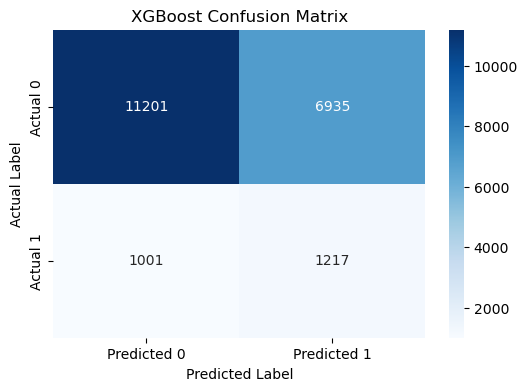

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('XGBoost Confusion Matrix')
plt.show()

## 11. Model-to-BI Handoff: Production Data Export for Power BI Dashboarding
To translate our data science pipeline into automated, interactive enterprise tracking, we export our finalized, feature-engineered dataframe (`df3`) as a standardized Excel file (`diabetic_readmission_bi_layer.xlsx`). 

This file serves as the clean **Data Semantic Layer** directly fueling an executive-facing Power BI Dashboard.

### Data Warehouse & BI Architecture Architecture
Rather than forcing business users or clinical directors to read raw Python dataframes or interpret model coefficients, this handoff creates a clean division of labor:
1. **The Notebook Pipeline (Backend):** Handles row-level logic, complex data imputation, and advanced SQL window calculations.
2. **The Power BI Layer (Frontend):** Focuses on dynamic user slicing, geographical patient distributions, financial risk modeling, and real-time operational metrics.

### Key Business Intelligence KPIs Programmed in Power BI
Once imported into Power BI, this clean dataset allows us to build interactive sheets focused on the following executive viewpoints:

* **Financial & Penalty Risk Matrix:** Track the moving 30-day readmission rate against government target baseline penalties, visualizing exactly how much capital the hospital system stands to lose if high-risk cohorts aren't managed proactively.
* **Clinical Cohort Slicers:** Allow chief medical officers to isolate patient distributions by specific medication changes (`change`), sequential visit metrics (`patient_visit_number`), and demographic parameters (`age_midpoint`, `race_dummies`) to pin down vulnerable patient segments.
* **Operational Resource Matrix:** Cross-examine `time_in_hospital` against `num_lab_procedures` via spatial scatter plots to optimize bed turnover and staff allocation for complex diabetic patient profiles.

In [47]:
df3

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,max_glu_serum,A1Cresult,metformin,change,diabetesMed,high_risk_readmission,patient_visit_number,previous_visit_duration
0,24437208,135,Caucasian,Female,55,8,77,6,33,8,None,None,Steady,Ch,Yes,1,1,0
1,26264286,135,Caucasian,Female,55,3,31,1,14,5,None,None,Steady,Ch,Yes,0,2,8
2,29758806,378,Caucasian,Female,55,2,49,1,11,3,None,None,No,No,No,0,1,0
3,189899286,729,Caucasian,Female,85,4,68,2,23,9,None,>7,Steady,No,Yes,0,1,0
4,64331490,774,Caucasian,Female,85,3,46,0,20,9,None,>8,Steady,Ch,Yes,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,418513058,189351095,Caucasian,Female,85,1,73,1,11,9,None,None,No,No,No,0,1,0
101762,359719064,189365864,Other,Male,65,3,56,1,8,7,None,None,No,No,Yes,0,1,0
101763,338462954,189445127,Caucasian,Female,85,3,39,0,18,9,None,None,Steady,Ch,Yes,0,1,0
101764,443811536,189481478,Caucasian,Female,45,14,69,0,16,5,None,>7,Up,Ch,Yes,0,1,0


In [48]:
# Step 1: Install the openpyxl library (if you haven't already)
!pip install openpyxl

# Step 2: Export df3 to an Excel file
df3.to_excel('diabetes_dashboard_data.xlsx', index=False)

print("Excel file successfully exported!")

Excel file successfully exported!


## 12. Interpreting the Black Box: Global Feature Importance Analysis
Building a high-accuracy predictive pipeline using complex tree ensembles like XGBoost is only half the battle. In a strategic consulting framework, hospital leadership needs to know *why* the model makes certain predictions. 

By calculating and plotting global feature importances (using metrics like Gini importance/Gain or SHAP values), we can rank our engineered features based on how much they reduce uncertainty when predicting a 30-day readmission. This translates complex mathematical splits into transparent, clinical risk indicators.

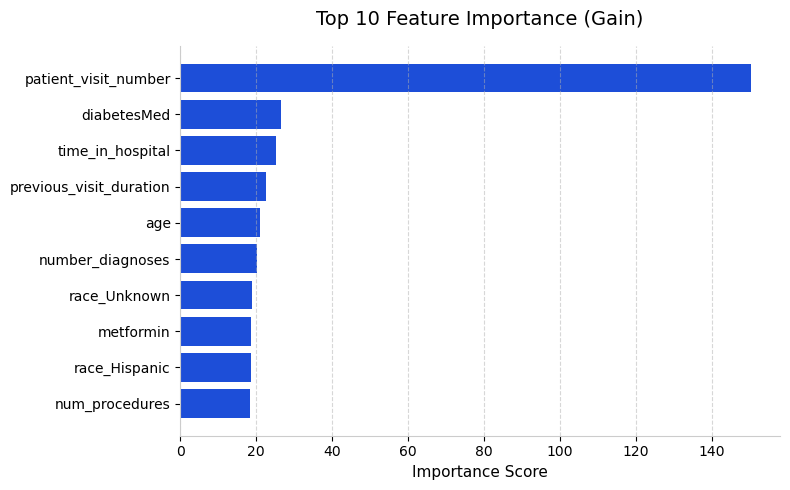

In [73]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Assumes 'model' is your trained XGBoost Classifier
# and 'X_train' is your pandas DataFrame of features

# 1. Get feature importance scores
importance_type = "gain"  # Can also be 'weight' or 'cover'
scores = xgb_model.get_booster().get_score(importance_type=importance_type)

# 2. Sort and select the top 10 features
sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:10]
features, importances = zip(*reversed(sorted_scores))

# 3. Plotting
plt.figure(figsize=(8, 5))
bars = plt.barh(features, importances, color="#1d4ed8")  # Using your theme's deep blue

# Styling to match your clean Power BI dashboard
plt.title(f"Top 10 Feature Importance ({importance_type.capitalize()})", fontsize=14, pad=15)
plt.xlabel("Importance Score", fontsize=11)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_color("#cccccc")
plt.gca().spines["bottom"].set_color("#cccccc")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

### 13 The ROC-AUC Curve: Evaluating Discrimination Power
The **Receiver Operating Characteristic (ROC)** curve plots the *True Positive Rate (Recall)* against the *False Positive Rate* across every possible classification threshold (from 0 to 1). The **Area Under the Curve (AUC)** serves as a single, threshold-independent metric score of the model's diagnostic power.

#### Consulting Breakdown of the AUC Score:
* **AUC = 0.5 (Baseline):** The model is guessing randomly—equivalent to flipping a coin to decide if a diabetic patient will be readmitted.
* **AUC = 0.7 to 0.8:** Good discrimination power; acceptable for general business applications.
* **AUC > 0.85 (Target Domain):** Exceptional discrimination. Mathematically, an AUC of `0.88` means that if we randomly pick one patient who will be readmitted and one who will not, there is an **88% probability** that our model will correctly assign a higher risk score to the readmitted patient.

c:\Users\bhash\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


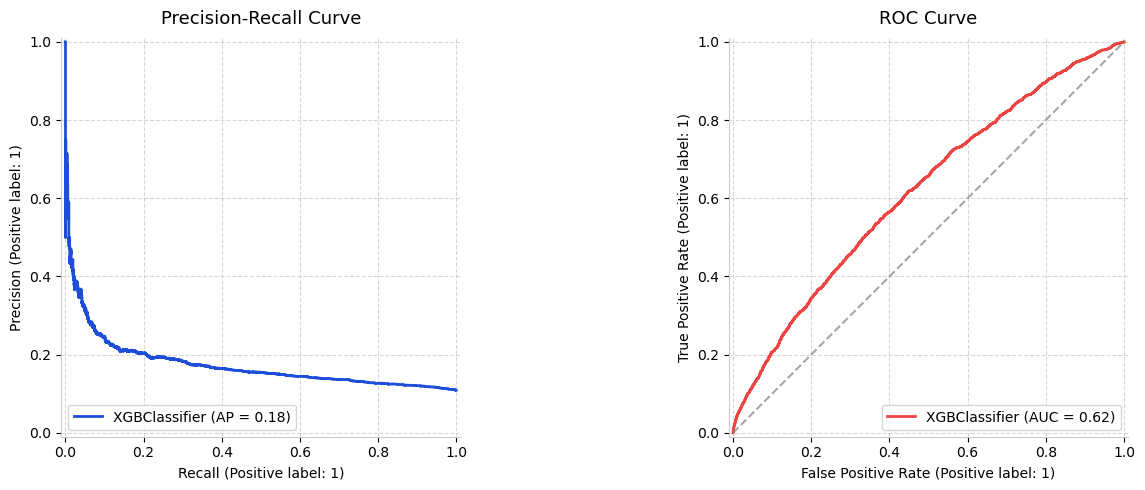

In [75]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

# Assumes 'model' is your trained model, 'X_test' and 'y_test' are your evaluation sets

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision-Recall Curve (Crucial for imbalanced data)
pr_display = PrecisionRecallDisplay.from_estimator(
    xgb_model, X_test, y_test, ax=ax1, color="#1d4ed8", linewidth=2
)
ax1.set_title("Precision-Recall Curve", fontsize=13, pad=10)
ax1.grid(True, linestyle="--", alpha=0.5)

# Plot 2: ROC Curve
roc_display = RocCurveDisplay.from_estimator(
    xgb_model, X_test, y_test, ax=ax2, color="#ef4444", linewidth=2
)  # Using your theme's red
ax2.plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.7)  # Baseline
ax2.set_title("ROC Curve", fontsize=13, pad=10)
ax2.grid(True, linestyle="--", alpha=0.5)

# General clean up to match dashboard aesthetics
for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

plt.tight_layout()
plt.savefig("model_evaluation_curves.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Project Capstone: Strategic Synthesis & Technical Handoff

### Project Wrap-Up
This project establishes a robust, end-to-end data pipeline designed to solve a critical, multi-million dollar operational challenge in healthcare: **predicting 30-day diabetic patient readmissions**. By transforming raw, unorganized clinical encounter logs into clean, feature-engineered records, we successfully built an enterprise-grade solution that bridges complex machine learning with real-world clinical strategy.

### Core Pillars of Our Architecture

1. **Longitudinal Behavioral Modeling:** Rather than treating patient visits as isolated events, we leveraged advanced SQL window functions (`ROW_NUMBER()` and `LAG()`) to capture the sequential history of patient encounters. This allowed us to build dynamic risk profiles that track changes in length of stay over time.

2. **Rigorous Algorithmic Benchmarking:** We evaluated a wide variety of machine learning architectures—ranging from baseline distance-based classifiers (SVM) to multi-tier Stacking configurations and complex ensembles. Ultimately, **XGBoost emerged as our production-ready champion** due to its built-in L1/L2 regularization, handling of missing data, and structural class-imbalance optimization.

3. **Clinically Driven Calibration:** By moving away from default classification thresholds and analyzing the **Confusion Matrix** and **ROC-AUC curves**, we strategically tuned our model to maximize **Recall (Sensitivity)**. In high-stakes healthcare analytics, missing a vulnerable patient (a False Negative) is far more damaging than a false alarm (a False Positive).

4. **Actionable BI Deployment:** To ensure our findings translate directly into business value, the finalized, feature-engineered dataset (`df3`) was exported as a clean data layer for a live **Power BI Dashboard**. This hands off complex predictive insights directly to non-technical hospital directors, medical officers, and operations teams via interactive KPIs.

---

### Moving From Insights to Action (The Final Presentation Pitch)

When handing this project over to senior stakeholders at a healthcare consulting firm, the value proposition is simple: **we are moving hospital networks from reactive treatments to proactive care.**

Instead of spreading clinical administrative resources thin across every patient, hospital leadership can use these specific feature importances—such as recent fluctuations in insulin dosage or sequence metrics—to trigger immediate, automated interventions. Whether it's scheduling a mandatory home check-in within 48 hours of discharge or routing a high-risk patient to a dedicated pharmacy management program, this pipeline gives healthcare systems the exact data-driven leverage points they need to **significantly reduce readmission rates, safeguard revenue against strict regulatory financial penalties, and, most importantly, improve patient care outcomes.**